# Does an Inverted Yield Curve Reliably Predict Recessions?

**Aidan Braccia — ECON 630, Assignment 6**

Question, data sources, and method are laid out in `Plan.md`. This notebook
follows that plan stage by stage.

## Stage 1 — Data pull, validation, and cleaning

Everything is pulled live from FRED on each run, so no CSVs are stored in the
repo. A spot check on the spread runs before any analysis, so a wrong sign or
bad series fails loudly instead of quietly corrupting downstream results.

In [1]:
import os
import pandas as pd
from dotenv import load_dotenv
from fredapi import Fred

load_dotenv()                                   # reads FRED_API_KEY from .env (gitignored)
fred = Fred(api_key=os.getenv("FRED_API_KEY"))  # key is never typed into the notebook

### Pull the three series

Each `get_series` call returns a plain `pd.Series` with a `DatetimeIndex` and no
column name — one value per month.

In [2]:
# Each call downloads one full series from FRED as a pd.Series indexed by date
gs10  = fred.get_series("GS10")   # 10-Year Treasury Constant Maturity Rate, monthly, percent
gs2   = fred.get_series("GS2")    # 2-Year  Treasury Constant Maturity Rate, monthly, percent
usrec = fred.get_series("USREC")  # NBER recession indicator, monthly, 1 = recession

# Print each series' length and date range, to confirm the pull worked
for name, s in [("GS10", gs10), ("GS2", gs2), ("USREC", usrec)]:
    print(f"{name:6} {len(s):5} observations   {s.index.min():%Y-%m} to {s.index.max():%Y-%m}")

GS10     882 observations   1953-04 to 2026-09
GS2      604 observations   1976-06 to 2026-09
USREC   2062 observations   1854-12 to 2026-09


### Trim to the sample period and build the spread

The sample starts in 1976-06, the first month of FRED's `GS2` series, so this is
the longest window the data allows. It covers three monetary policy regimes
(the late-1970s inflation, the Volcker disinflation, and the post-1990 era), six
NBER recessions (1980, 1981–82, 1990–91, 2001, 2007–09, 2020) and the 2022–24
inversion episode.

`.loc[START:]` keeps every month from June 1976 onward. It is a slice from that
date to the end of the series, not a match on that single date.

The sign is the thing to get right: `spread = GS10 - GS2`, so an inversion is
`spread < 0`. Flipping it would silently invert the entire story.

In [3]:
START = "1976-06-01"   # first month of GS2
# Trim all three series to the same start date so they line up month by month
gs10  = gs10.loc[START:]
gs2   = gs2.loc[START:]
usrec = usrec.loc[START:]

# pandas subtracts by matching dates, not by position in the Series
spread = gs10 - gs2   # 10y minus 2y, so inversion is spread < 0

print(f"sample: {spread.index.min():%Y-%m} to {spread.index.max():%Y-%m}  ({len(spread)} months)")

sample: 1976-06 to 2026-09  (604 months)


### Validation check

The curve is known to have been inverted in **November 2006** (−0.14), ahead of
the 2007–09 recession, so the spread that month must be negative. This check
fails if the spread sign is flipped.

In [4]:
# .item() pulls the single number out of the one-month selection. If the
# spread is not negative, the assert stops the notebook with this message.
assert spread.loc["2006-11"].item() < 0, \
    "expected the curve to be inverted in 2006-11, ahead of the 2007-2009 recession"

# Second sanity check: the spread should stay within a few percentage points
print(f"spread range: {spread.min():.2f} to {spread.max():.2f} percentage points")

spread range: -2.13 to 2.83 percentage points


## Stage 2 — Charts

Two charts, as laid out in `Plan.md`:

1. the spread over time with recession shading,
2. the lead times side by side.

Both share one set of colors so they read as a single system: blue for the
series, red reserved for inversion, neutral gray for recession context and
chrome. Blue and red are a diverging pair — they encode the polarity of the
spread (above or below zero), not two arbitrary categories.

In [5]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch   # colored squares for legend entries

# Color palette shared by both charts
SURFACE = "#fcfcfb"   # chart surface
INK     = "#0b0b0b"   # primary text
INK2    = "#52514e"   # secondary text
MUTED   = "#898781"   # axis labels
GRID    = "#e1e0d9"   # hairline gridlines
AXIS    = "#c3c2b7"   # baseline, recession bands
BLUE    = "#2a78d6"   # the spread series
RED     = "#e34948"   # inversion


def style(ax):
    """Shared chart chrome: recessive grid, no top/right spines, muted ticks."""
    ax.set_facecolor(SURFACE)
    ax.grid(axis="y", color=GRID, lw=0.8, zorder=0)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(AXIS)
        ax.spines[s].set_lw(0.8)
    ax.tick_params(colors=MUTED, labelsize=9, length=0)


def source(fig):
    """Add the data-source note under the chart, with the sample's date range."""
    fig.text(0.005, -0.02,
             "Source: FRED (GS10, GS2, USREC). Monthly, "
             f"{spread.index[0]:%Y-%m} to {spread.index[-1]:%Y-%m}.",
             color=MUTED, fontsize=8, ha="left", va="top")

### Defining an inversion episode

The spread crosses zero more often than there are distinct inversions. The
2006–07 episode dips below zero, pops barely positive for a month or two, and
dips again. Treating each crossing as its own episode would invent inversions
that nobody would describe as separate.

Runs of `spread < 0` separated by a gap of **three months or less** are merged
into one episode (`MAX_GAP = 3`, from `Plan.md`). Single-month dips are kept
rather than filtered out: 1990-03 and 1998-06 are both one-month dips.

### Assigning a lead time to each recession

Lead times are counted **per recession, not per episode**, using the rule in
`Plan.md`. For each recession, take the most recent episode that started in the
**`SIGNAL_WINDOW` months before it**, whether or not that episode is still going
when the recession starts. The lead time runs from the episode's first month to
the recession's first month. A recession with no episode in that window is
recorded as **no inversion**.

An episode is a **false alarm** if no recession begins within **24 months of its
onset** (`SIGNAL_WINDOW = 24`, from `Plan.md`). False alarms are left out when
lead times are assigned, so a later recession can never be matched to one. The
window sits just above the longest real lead in the sample (23 months), so it is
a choice.

Each episode then gets one of three roles:
- **signal:** it produced a recession's lead time;
- **superseded:** a later episode came before the same recession;
- **false alarm:** no recession within `SIGNAL_WINDOW` months of its onset.

In [6]:
MAX_GAP       = 3    # months of non-inversion tolerated inside a single episode
SIGNAL_WINDOW = 24   # an episode with no recession this many months after onset is a false alarm

# --- Step 1: find runs of consecutive inverted months ---
inverted = spread < 0   # True in every inverted month
# run_id goes up by 1 every time inverted switches between True and False,
# so each unbroken run of same-valued months shares one id
run_id   = (inverted != inverted.shift()).cumsum()
# keep only the inverted runs, and record each one's first and last month
runs     = [(g.index[0], g.index[-1]) for _, g in inverted[inverted].groupby(run_id[inverted])]

# --- Step 2: merge runs separated by short gaps into episodes ---
episodes = []
for start, end in runs:
    if episodes:
        prev_end = episodes[-1][1]
        # months strictly between the previous run's end and this run's start
        gap = (start.year - prev_end.year) * 12 + (start.month - prev_end.month) - 1
        if gap <= MAX_GAP:
            episodes[-1] = (episodes[-1][0], end)   # extend the previous episode
            continue
    episodes.append((start, end))                   # otherwise start a new episode

# one row per episode, with its deepest (most negative) spread
ep = pd.DataFrame([{"start": s, "end": e, "min_spread": spread.loc[s:e].min()}
                   for s, e in episodes])

# --- Step 3: recession onsets and helper functions ---
# recession onsets: the month USREC flips 0 -> 1
onsets = list(usrec.index[(usrec == 1) & (usrec.shift(1) == 0)])


def months_between(a, b):
    """Whole calendar months from date a to date b."""
    return (b.year - a.year) * 12 + (b.month - a.month)


LAST = spread.index[-1]   # last month of data, used for episodes with no recession yet


def next_recession(start):
    """First recession onset after a date, or NaT if none has happened yet."""
    later = [d for d in onsets if d > start]
    return later[0] if later else pd.NaT


# --- Step 4: flag false alarms ---
# false alarm: no recession within SIGNAL_WINDOW months of onset (Plan.md)
ep["next_recession"] = ep["start"].map(next_recession)
# if no recession has happened yet, count the months up to the end of the data
ep["false_alarm"] = [
    (months_between(s, r) > SIGNAL_WINDOW) if pd.notna(r) else (months_between(s, LAST) > SIGNAL_WINDOW)
    for s, r in zip(ep["start"], ep["next_recession"])
]

# --- Step 5: one lead time per recession ---
# one row per recession: the most recent non-false-alarm episode that started in the
# SIGNAL_WINDOW months before it (Plan.md) - the same window as the false-alarm rule
rows, used = [], {}   # used maps each signal episode's start to its recession
for onset in onsets:
    window_start = onset - pd.DateOffset(months=SIGNAL_WINDOW)
    # candidates: episodes that started inside the window and are not false alarms
    before = ep[(ep["start"] < onset) & (ep["start"] >= window_start) & ~ep["false_alarm"]]
    if before.empty:   # no candidate, e.g. 2020
        rows.append({"recession": onset, "stretch": pd.NaT, "lead": None, "status": "no inversion"})
        continue
    stretch = before["start"].iloc[-1]   # the most recent candidate sets the lead
    used[stretch] = onset
    rows.append({"recession": onset, "stretch": stretch,
                 "lead": months_between(stretch, onset), "status": "bar"})
leads = pd.DataFrame(rows).astype({"lead": "Int64"})   # whole months; blank for no bar

# --- Step 6: label each episode's role ---
ep["recession"] = ep["start"].map(used)   # matched recession, NaT if none
# signal = set a lead; false alarm = flagged above; open = no recession yet and
# still inside the window; superseded = a later episode set the same recession's lead
ep["role"] = ["signal" if s in used else "false alarm" if fa
              else "open" if pd.isna(r) else "superseded"
              for s, fa, r in zip(ep["start"], ep["false_alarm"], ep["next_recession"])]

print(ep.to_string(index=False))
print()
print(leads.to_string(index=False))

     start        end  min_spread next_recession  false_alarm  recession        role
1978-09-01 1980-04-01       -2.13     1980-02-01        False 1980-02-01      signal
1980-09-01 1982-06-01       -1.36     1981-08-01        False 1981-08-01      signal
1989-01-01 1989-09-01       -0.32     1990-08-01        False        NaT  superseded
1990-03-01 1990-03-01       -0.04     1990-08-01        False 1990-08-01      signal
1998-06-01 1998-06-01       -0.02     2001-04-01         True        NaT false alarm
2000-02-01 2000-12-01       -0.41     2001-04-01        False 2001-04-01      signal
2006-02-01 2007-05-01       -0.14     2008-01-01        False 2008-01-01      signal
2022-07-01 2024-08-01       -0.93            NaT         True        NaT false alarm

 recession    stretch  lead       status
1980-02-01 1978-09-01    17          bar
1981-08-01 1980-09-01    11          bar
1990-08-01 1990-03-01     5          bar
2001-04-01 2000-02-01    14          bar
2008-01-01 2006-02-01    23  

### Chart 1 — The spread over time

The fill is split at zero: blue above, red below. A single series needs no
legend, so the legend identifies only the two shaded encodings.

The deepest inversions in the sample are the 1978–82 ones, during the Volcker
disinflation. They also continue *into* the 1980 and 1981–82 recessions, where
every later inversion ended before its recession began. The 2020 recession band
is **two months wide** and easy to mistake for a gridline at this scale.

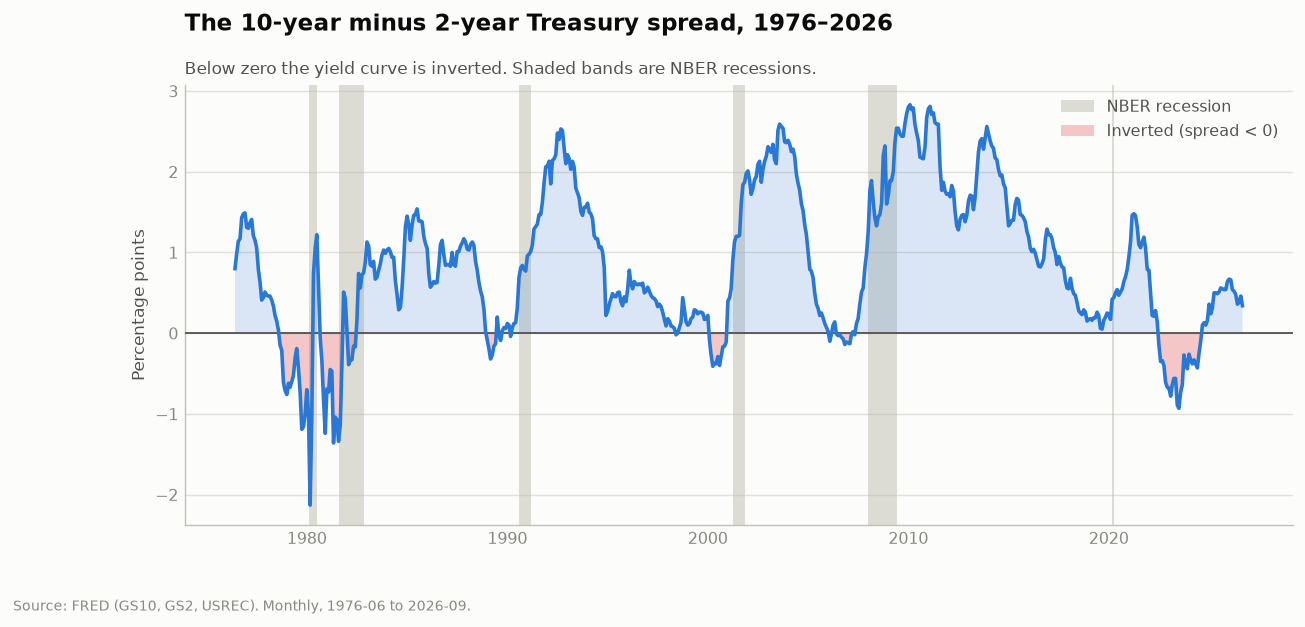

In [7]:
fig, ax = plt.subplots(figsize=(11, 4.4), dpi=130, facecolor=SURFACE)
style(ax)

# Gray recession bands: transform makes them span the full height of the chart
ax.fill_between(usrec.index, 0, 1, where=usrec == 1, transform=ax.get_xaxis_transform(),
                color=AXIS, alpha=.55, lw=0, zorder=1)
# Fill between the line and zero: light blue above, red below (inverted)
ax.fill_between(spread.index, spread, 0, where=spread >= 0, color=BLUE, alpha=.16, lw=0, zorder=2)
ax.fill_between(spread.index, spread, 0, where=spread < 0,  color=RED,  alpha=.30, lw=0, zorder=2)
ax.axhline(0, color=INK2, lw=1, zorder=3)        # zero line: the inversion threshold
ax.plot(spread.index, spread, color=BLUE, lw=2, zorder=4)   # the spread, drawn on top

# Labels: units on the y-axis, then a title and a one-line subtitle
ax.set_ylabel("Percentage points", color=INK2, fontsize=9.5)
ax.set_title(f"The 10-year minus 2-year Treasury spread, {spread.index[0]:%Y}–{LAST:%Y}",
             color=INK, fontsize=13, fontweight="bold", loc="left", pad=30)
ax.text(0, 1.015, "Below zero the yield curve is inverted. Shaded bands are NBER recessions.",
        transform=ax.transAxes, color=INK2, fontsize=9.5, va="bottom")
# Legend for the two shaded areas only; the blue line is named in the title
ax.legend(handles=[Patch(facecolor=AXIS, alpha=.55, label="NBER recession"),
                   Patch(facecolor=RED, alpha=.30, label="Inverted (spread < 0)")],
          loc="upper right", frameon=False, fontsize=9, labelcolor=INK2)
source(fig)
plt.show()

### Chart 2 — Lead times, one per recession

The plan called this the chart that decides the question: a consistent signal
produces bars of similar length, a noisy one produces scatter. There is one row
per recession. The 2020 row has no bar because no inversion started in the 24
months before it. The most recent inversion before 2020 began in 2006-02,
**169 months** earlier, more than seven times the longest real lead.

The two false alarms, 1998-06 and 2022-07, are drawn open and hatched rather
than filled, and they sit below the recessions because they are not recessions.
Each bar runs from the episode's onset to the next recession or, for 2022, to
the end of the data. Both run past the dashed 24-month line (`SIGNAL_WINDOW`),
and that is what makes them false alarms. They carry their own labels, so the
distinction never rests on the hatching alone.

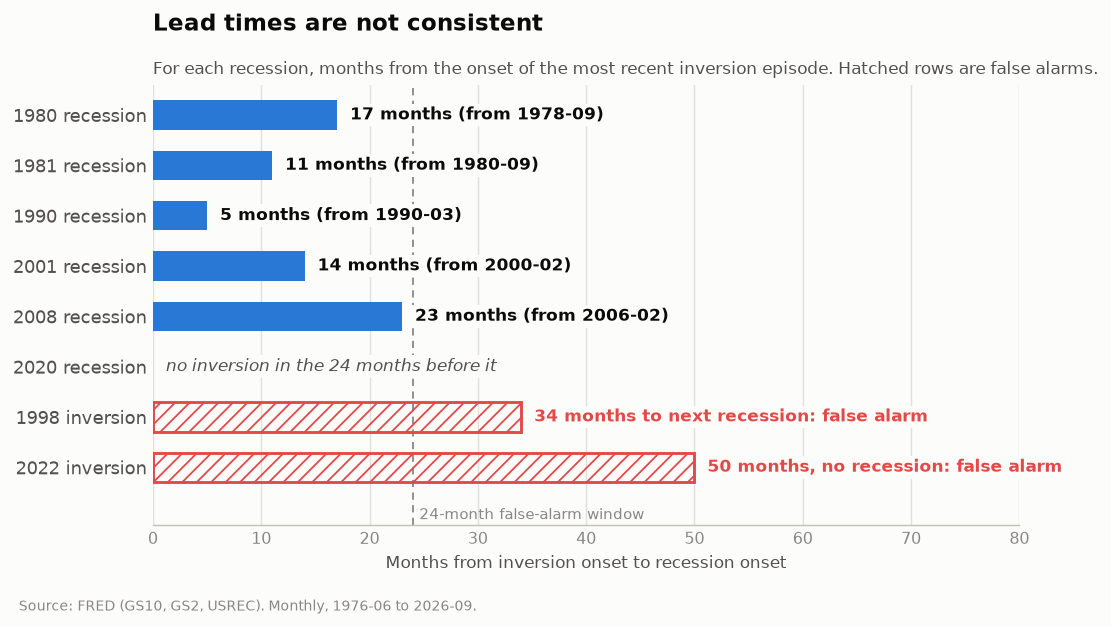

In [8]:
# Chart rows: one per recession, then one per false alarm
false_alarms = ep[ep["role"] == "false alarm"]
chart_rows = [(f"{r.recession:%Y} recession", r.lead, r.status, r.stretch)
              for _, r in leads.iterrows()]
# a false alarm's bar runs from its onset to the next recession, or to the end of the data
chart_rows += [(f"{r.start:%Y} inversion",
                months_between(r.start, LAST if pd.isna(r.next_recession) else r.next_recession),
                "false alarm", r.next_recession)
               for _, r in false_alarms.iterrows()]

fig, ax = plt.subplots(figsize=(8.6, 4.4), dpi=130, facecolor=SURFACE)
# Same styling as chart 1, but with vertical gridlines because the bars are horizontal
ax.set_facecolor(SURFACE)
ax.grid(axis="x", color=GRID, lw=0.8)
ax.set_axisbelow(True)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color(AXIS); ax.spines["bottom"].set_lw(0.8)
ax.tick_params(colors=MUTED, labelsize=9, length=0)

y_rows = list(range(len(chart_rows)))[::-1]   # first row drawn at the top
for i, (label, lead, status, stretch) in zip(y_rows, chart_rows):
    if status == "no inversion":   # 2020: a text note instead of a bar
        ax.text(1.2, i, f"no inversion in the {SIGNAL_WINDOW} months before it",
                va="center", ha="left", fontsize=9.5, color=INK2, style="italic",
                zorder=3, bbox=dict(facecolor=SURFACE, edgecolor="none", pad=1.5))
        continue
    # recessions get solid blue bars; false alarms get hatched red outlines
    alarm = status == "false alarm"
    ax.barh(i, lead, height=.58, zorder=2,
            color="none" if alarm else BLUE,
            edgecolor=RED if alarm else "none",
            lw=1.6, hatch="///" if alarm else None)
    # text label at the end of each bar
    if alarm:
        label = (f"{lead} months, no recession: false alarm" if pd.isna(stretch)
                 else f"{lead} months to next recession: false alarm")
    else:
        label = f"{lead} months (from {stretch:%Y-%m})"
    ax.text(lead + 1.2, i, label, va="center", ha="left", fontsize=9.5,
            fontweight="bold", color=RED if alarm else INK, zorder=3,
            bbox=dict(facecolor=SURFACE, edgecolor="none", pad=1.5))

# Dashed line at the 24-month false-alarm cutoff, labeled below the bars
ax.axvline(SIGNAL_WINDOW, color=MUTED, lw=1, ls=(0, (4, 3)), zorder=1)
ax.set_ylim(-1.15, len(chart_rows) - .4)
ax.text(SIGNAL_WINDOW + .6, -.95, f"{SIGNAL_WINDOW}-month false-alarm window",
        fontsize=8.5, color=MUTED, va="center", ha="left")

# Labels: one tick per row, months on the x-axis, then a title and subtitle
ax.set_yticks(y_rows)
ax.set_yticklabels([row[0] for row in chart_rows], color=INK2, fontsize=10)
ax.set_xlim(0, 80)
ax.set_xlabel("Months from inversion onset to recession onset", color=INK2, fontsize=9.5)
ax.set_title("Lead times are not consistent", color=INK, fontsize=13,
             fontweight="bold", loc="left", pad=30)
ax.text(0, 1.015, "For each recession, months from the onset of the most recent inversion episode. Hatched rows are false alarms.",
        transform=ax.transAxes, color=INK2, fontsize=9.5, va="bottom")
source(fig)
plt.show()

## Stage 3 — Statistical test

One test from `Plan.md`: a logistic regression of recession status on the
spread twelve months earlier, fit once with autocorrelation-robust (HAC)
standard errors.

First, the remaining cleaning step. `inverted` was already built in Stage 2;
`spread_lag12` is new. The regression frame drops only the twelve leading
months that the lag leaves empty.

In [9]:
spread_lag12 = spread.shift(12)  # the spread as it stood 12 months before each date

# Outcome and lagged predictor side by side, lined up by date
data = pd.DataFrame({"usrec": usrec, "spread_lag12": spread_lag12}).dropna()  # drops the 12 empty lag rows

# Quick counts: inverted months, and how many months are recessions
print(f"inverted months: {inverted.sum()} of {len(inverted)}")
print(f"observations: {len(data)}   recession months: {int(data['usrec'].sum())}"
      f"  ({data['usrec'].mean():.1%} of the sample)")

inverted months: 99 of 604
observations: 592   recession months: 58  (9.8% of the sample)


### Does the spread 12 months ago predict a recession now?

`USREC ~ spread_lag12`, one lag only. This goes past what has been lectured —
`statsmodels` appeared in the toolkit overview but was not taught — so each
piece is spelled out.

- `sm.add_constant` adds the intercept column. Without it the model is forced
  through zero, which silently changes what the coefficient means.
- `Logit(y, X).fit()` estimates by maximum likelihood.
- `cov_type="HAC", cov_kwds={"maxlags": 12}` gives Newey-West standard errors
  with a 12-month bandwidth.
- The coefficient is on the **log-odds** scale, so `np.exp(coef)` converts it to
  an odds ratio per one-percentage-point change in the spread.

The standard errors are HAC because recession months come in clumps, six
contiguous runs in this sample. Ordinary standard errors would treat those few
episodes as hundreds of independent observations and overstate the precision.

In [10]:
import numpy as np
import statsmodels.api as sm

y = data["usrec"]                             # outcome: 1 in a recession month, 0 otherwise
X = sm.add_constant(data[["spread_lag12"]])   # intercept + one regressor

# Fit by maximum likelihood, with HAC (Newey-West) standard errors over 12 months
logit = sm.Logit(y, X).fit(disp=0, cov_type="HAC", cov_kwds={"maxlags": 12})
print(logit.summary())   # coefficients, standard errors, z-statistics, p-values

# Turn the log-odds coefficient into an odds ratio, which is easier to read
coef = logit.params["spread_lag12"]
print(f"\ncoefficient on spread_lag12: {coef:.3f}")
print(f"odds ratio per +1pp of spread: {np.exp(coef):.3f}")
print(f"i.e. each extra percentage point of spread 12 months ago multiplies the")
print(f"odds of being in recession by about {np.exp(coef):.2f}.")

                           Logit Regression Results                           
Dep. Variable:                  usrec   No. Observations:                  592
Model:                          Logit   Df Residuals:                      590
Method:                           MLE   Df Model:                            1
Date:                Fri, 02 Oct 2026   Pseudo R-squ.:                  0.1807
Time:                        20:17:09   Log-Likelihood:                -155.50
converged:                       True   LL-Null:                       -189.80
Covariance Type:                  HAC   LLR p-value:                 1.206e-16
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -1.5838      0.378     -4.192      0.000      -2.324      -0.843
spread_lag12    -1.5005      0.568     -2.642      0.008      -2.614      -0.387

coefficient on spread_lag12: -1.501
odds ra

The coefficient is about **−1.50**, an odds ratio of about **0.22** per
percentage point: a flatter or inverted curve a year earlier goes with higher
odds of recession now. With HAC standard errors, p = **0.008**, significant at
the 1% level.

Two cautions keep this from being the whole story:
- Six recessions is still a small sample, as `Plan.md` warns up front. This is
  a compact description of the pattern the charts show, not a well-powered
  test.
- The regression says the spread *level* a year earlier is associated with
  recession. It says nothing about *timing*. Chart 2 shows lead times from
  5 to 23 months, plus two false alarms, and 2020 had no inversion in the 24
  months before it.

---

## Conclusion

**The question:** does a negative 10-year minus 2-year spread reliably precede
U.S. recessions, or is it noisier than its reputation suggests?



**Given this evidence** the inversion is a real signal that a recession is likely. 
It is a poor signal of when and it sometimes fires when no recession follows. 
My expectation going in was that inversion would precede most recessions but with some inconsistency. 
That is close to what the data shows and the regression actually came out much stronger than my expectation. 

**What holds up:** 
1. **The association is strong.** In the logistic regression, the coefficient on the spread twelve months earlier 
   is -1.50, an odds ratio of 0.22 per percentage point, and with HAC standard errors  p = 0.008
2. **Most recessions were preceded by an inversion.** Five of the six recessions since 1976 had 
   an inversion episode start within the 24 months prior. 

**What doesn’t hold:**
1. **Lead times do not cluster.** They were 17, 11, 5, 14, and 23 months respectively. 
   Knowing an inversion has begun tells you little about when the recession 
   will arrive. Even the five is fragile as it came from a one-month dip of -0.04 in 1990-03 
2. **It also produces false alarms.** The 1998-06 dip was followed by a recession 34 months 
   later. The 2022-24 inversion, the deepest since the early 80s (-0.93) has 
   gone 50 months with no recession. 
3. **It missed a recession.** There were no inversions in the lead up before the recession 
   in 2020. A pandemic is not the kind of shock the yield curve prices, so this is a 
   limit on what the signal can see. 


**Caveats:** there are only six recessions in the sample, so the regression is very 
compact description of the pattern in the charts, not a well-powered test. 
the 24 month window is also a choice not a finding, it sits just above the 
longest lead and it decides which episodes count as false alarms. 

The summary is that the yield curve is a reliable indicator of 
recession risk, and an unreliable one for forecasting when a recession
 with truly begin.

---

## How I used Claude

I put `Plan.md` together before any of the code existed for the project, then had claude adjust the plan so that is was specific enough to build efficiently from. Then, I had claude work through the notebook one stage at a time (there were 3 total stages) and I checked each stage against the plan before moving on. Stage one, was a pretty easy stage for claude but it got the spread backwards, it had the 2yr minus the 10yr instead of the correct equation 10yr minus 2yr. Luckily the spot check assert I had written spotted this. Later on claude found that actually my spot check was off as it had 2007-09 with a spread of 0.51 because the 2006 inversion period had ended. As a result, I moved the check to November of 2006 (-0.14). Claude wanted to loosen it to, “any month in 2006”, but I pushed back and kept it as one named month for specificity. Also I got rid of a `fillna` claude had added and put an assert there. The lead-time rule took the most back and forth between claude and I. I noticed the 24-month window only ran forward, which is how 2020 got matched to an inversion from 169 months earlier. as a result, we made the window run both ways so that 2020 would count as a recession with no inversion which was the reality.  In the first full run I would describe claude as getting a bit, “excited”. It made the work and outputs more complex than they needed to be. Due to this I went back into the plan and worked with Claude to simplify the notebook to what was necessary for the assignment, not all the “bells and whistles”. Additionally, the final analysis did change from the plan. The sample period was originally from 1990 until present day but I later changed that to 1976 which gave us 6 recessions instead of four. I also added comments to the code later which was not in the original plan. All in all, besides the original plan where it was me telling Claude what to do, it felt more like a partnership, checking everything along the way.